# K-Means Clustering

This is the first **unsupervised** algorithm in the repository, so the big change is that there are no labels to learn from. Instead of predicting a known answer, the goal is to find natural groups hiding in the data on its own.

K-Means is the simplest way to do that. You guess how many groups there are (call it **k**), then repeat two steps until things settle: assign each point to its nearest group center, then move each center to the average of the points that joined it. The centers drift to the middle of the real groups, and you are left with k clusters.

I use the **seeds** dataset: 210 wheat kernels, each measured **7 ways** (area, perimeter, compactness, length, width, asymmetry, and groove length), coming from 3 varieties (Kama, Rosa, Canadian). The variety labels exist, but I hide them from the algorithm and only use them at the end to check how well the clusters match reality. Because there are 7 features, this is also a clean example of clustering in **more than two dimensions**, which works exactly the same as 2D, just with distance summed over all 7 measurements.

**A note on dataset choice.** I originally wanted to use a medical dataset here, but medical data tends to be noisy with lots of outliers and irregularly shaped clusters. K-Means is sensitive to all of that since it uses the mean to place centroids and assumes clusters are roughly round and similar in size. Rather than fight the noise, I picked the seeds dataset because its clean, well-separated groups really show the power of K-Means without anything getting in the way.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import warnings; warnings.filterwarnings("ignore")

sns.set_theme()
PALETTE = ["#5d32ca", "#82b600", "#e07b39"]   # purple, green, orange

# Load the seeds dataset: 210 wheat kernels with 7 physical measurements and a variety label
# Try the remote URL first, fall back to the local copy if unavailable
cols = ["area", "perimeter", "compactness", "kernel_length",
        "kernel_width", "asymmetry", "groove_length", "variety"]
try:
    df = pd.read_csv("https://raw.githubusercontent.com/Narahari917/seeds/master/seeds_dataset.csv",
                     sep=r"\s+", header=None, names=cols)
    variety_names = {1: "Kama", 2: "Rosa", 3: "Canadian"}
    df["variety"] = df["variety"].map(variety_names)
except Exception:
    df = pd.read_csv("../Datasets/seeds.csv")

# Separate features from labels — labels are only used at the end for validation
X_raw = df.drop(columns="variety").to_numpy()
true = df["variety"].to_numpy()

# Standardize: the 7 features are on different scales, and distance must treat them fairly
X = StandardScaler().fit_transform(X_raw)
print(len(X), "kernels |", X.shape[1], "features | varieties:", dict(df["variety"].value_counts()))

210 kernels | 7 features | varieties: {'Kama': np.int64(70), 'Rosa': np.int64(70), 'Canadian': np.int64(70)}


## The Algorithm

The whole thing is four small functions, and notice that **none of them mention the number of features**, they work im 2 dimensions or 7.

- **`assign`** computes the Euclidean distance from every point to every centroid across all features, then gives each point the label of its nearest centroid.
- **`update`** moves each centroid to the mean of the points currently assigned to it, so the center drifts toward the true middle of its group.
- **`inertia`** measures the total within-cluster spread, the sum of squared distances from each point to its centroid. This is the objective K-Means is quietly minimizing every iteration.
- **`k_means`** ties it together: drop k random centroids, alternate between assign and update until the centroids stop moving (or hit a max iteration cap), and record inertia each round so we can watch convergence.

Finally, **`best_k_means`** runs the algorithm multiple times with different random starting centroids and keeps the run with the lowest final inertia, since a bad initialization can trap K-Means in a suboptimal grouping.

In [10]:
def assign(X, C):
    # Euclidean distance from every point to every centroid, then pick the nearest
    dists = np.linalg.norm(X[:, None, :] - C[None, :, :], axis=2)
    return np.argmin(dists, axis=1)

def update(X, labels, C):
    # Move each centroid to the mean of its assigned points
    new = C.copy()
    for j in range(len(C)):
        pts = X[labels == j]
        if len(pts):
            new[j] = pts.mean(axis=0)
    return new

def inertia(X, labels, C):
    # Total squared distance from each point to its centroid, lower means tighter clusters
    return float(sum(((X[labels == j] - C[j]) ** 2).sum() for j in range(len(C))))

def k_means(X, k, seed=0, max_iter=100):
    rng = np.random.default_rng(seed)
    C = X[rng.choice(len(X), k, replace=False)].astype(float)  # random initial centroids
    track = []
    for _ in range(max_iter):
        labels = assign(X, C)
        track.append(inertia(X, labels, C))
        new = update(X, labels, C)
        if np.allclose(new, C):                   # centroids stopped moving — converged
            break
        C = new
    labels = assign(X, C)
    track.append(inertia(X, labels, C))
    return labels, C, track

def best_k_means(X, k, restarts=10):
    # Multiple restarts to avoid getting stuck on a bad initialization
    runs = [k_means(X, k, seed=s) for s in range(restarts)]
    return min(runs, key=lambda r: r[2][-1])

labels, C, track = best_k_means(X, 3)

print("=== Inertia Over Iterations ===")
for i, val in enumerate(track):
    print(f"  Iteration {i+1}: {val:.2f}")
print(f"\nFinal inertia: {track[-1]:.2f}")
print(f"Converged in {len(track)} iterations")
counts = np.unique(labels, return_counts=True)
print(f"Points per cluster: {{{', '.join(f'{int(k)}: {int(v)}' for k, v in zip(*counts))}}}")

=== Inertia Over Iterations ===
  Iteration 1: 822.84
  Iteration 2: 445.93
  Iteration 3: 432.90
  Iteration 4: 431.42
  Iteration 5: 431.28
  Iteration 6: 431.03
  Iteration 7: 430.74
  Iteration 8: 430.66
  Iteration 9: 430.66

Final inertia: 430.66
Converged in 9 iterations
Points per cluster: {0: 71, 1: 67, 2: 72}


## Watching It Converge

In 2D you can watch the centroids walk across the plane (which I will show later), but here the points live in 7-dimensional space, so there's nothing to plot directly. Instead I track the **inertia** (total spread) each round. It drops fast and then flattens, and that flattening *is* convergence, the centroids have stopped moving.

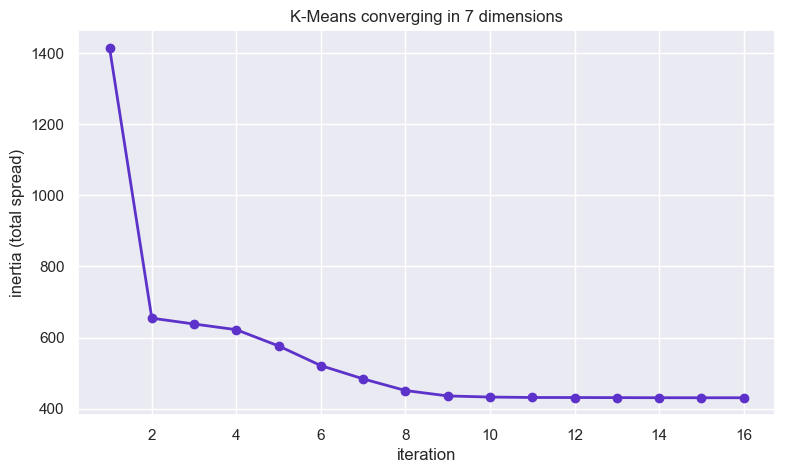

In [12]:
labels, C, track = k_means(X, 3, seed=1)
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(track) + 1), track, "o-", color="#5d32ca", lw=2)
plt.xlabel("iteration"); plt.ylabel("inertia (total spread)")
plt.title("K-Means converging in 7 dimensions")
plt.show()

## Step-by-Step: Watching the Centroids Move

The inertia curve above proves convergence, but it doesn't show *what's happening* to the clusters at each step. Below I run K-Means on just **two** of the seven features (kernel width and groove length) so that everything fits on a 2D plot and acts as a good visual (although not representative to what actaully happened in 7d but the same processs). At each iteration you can see:

- The **colored regions** (decision boundaries) showing which centroid owns each part of the space, any point landing in a region gets assigned to that cluster.
- The **data points** colored by their current cluster assignment.
- The **centroids** marked with a black-outlined star, watch them drift toward the center of their group until they settle.

The full algorithm uses all 7 features, but the mechanics are identical: assign, update, repeat. Two features just let us draw the picture and at iteration 11-12 it's easy to see the regions largely stop changing.

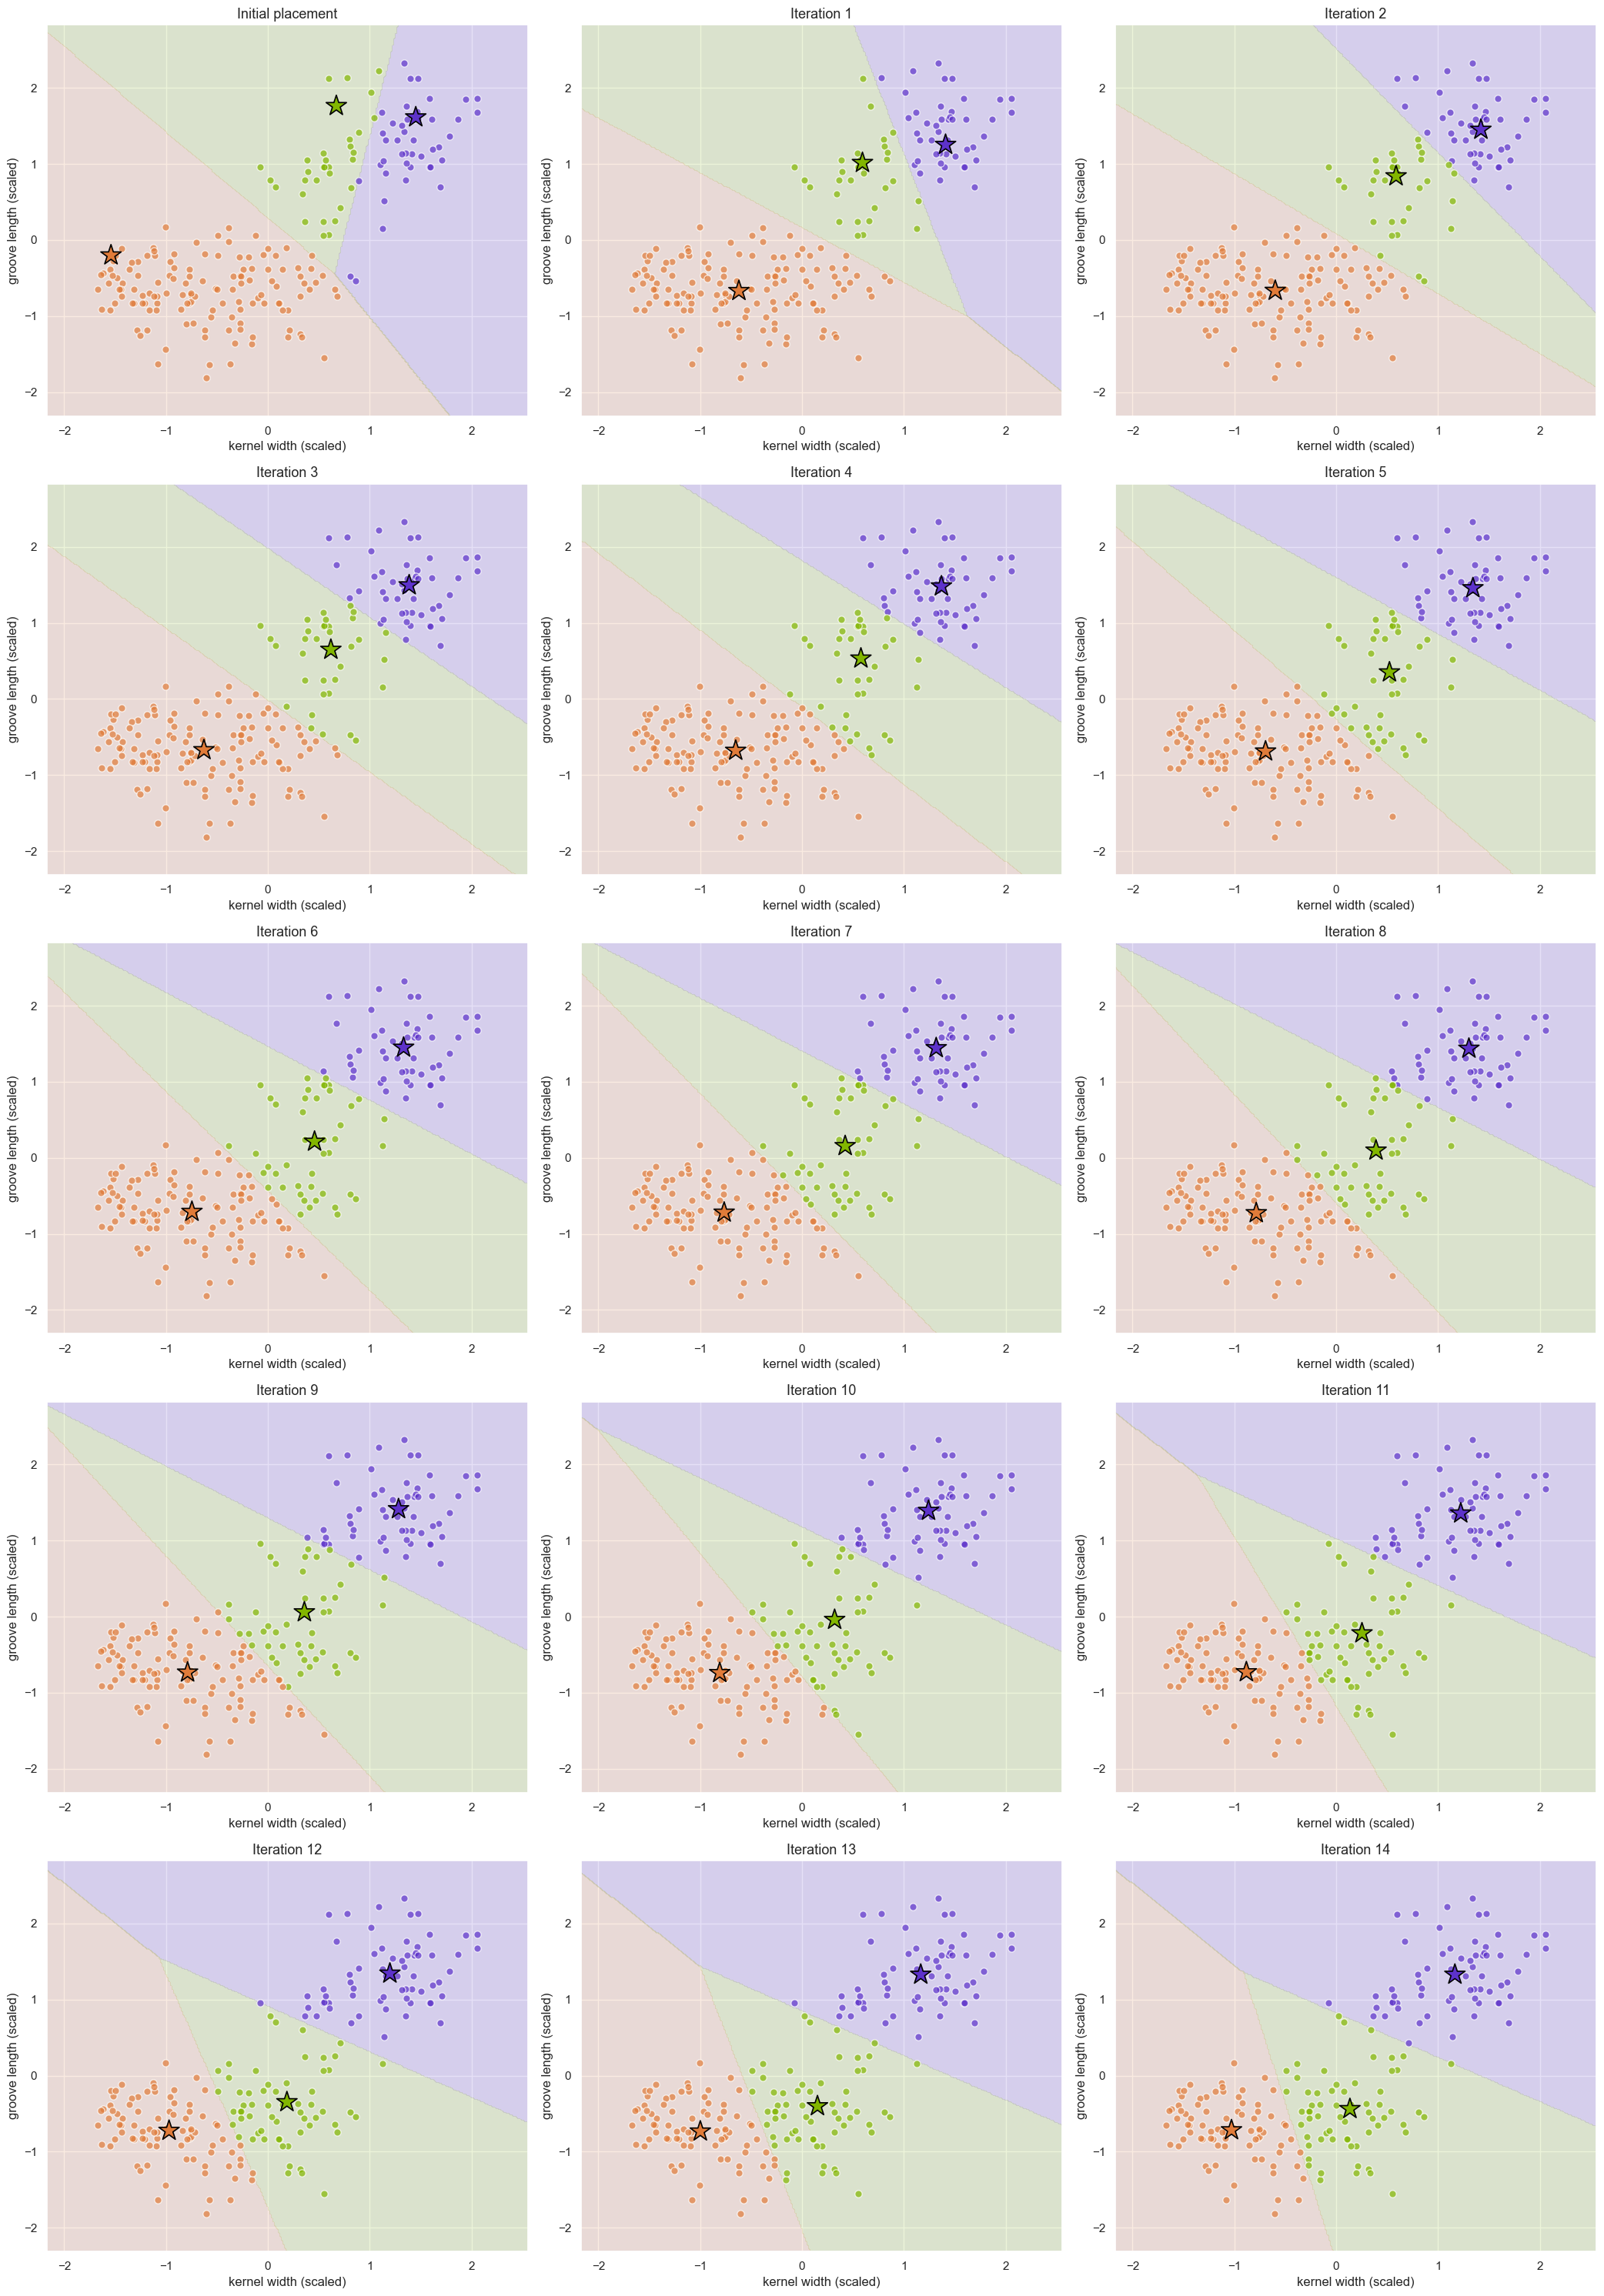

In [20]:
# Run K-Means on 2 features so we can visualize decision regions
X2 = StandardScaler().fit_transform(X_raw[:, [4, 6]])  # kernel_width, groove_length

# Manually step through assign/update and save centroids + labels at each iteration
rng = np.random.default_rng(1)
C2 = X2[rng.choice(len(X2), 3, replace=False)].astype(float)
history = []
# Record the initial random placement before any updates
labs = assign(X2, C2)
history.append((labs.copy(), C2.copy(), "Initial placement"))
for it in range(1, 15):
    new = update(X2, labs, C2)
    if np.allclose(new, C2):
        history[-1] = (labs.copy(), C2.copy(), f"Iteration {it} (converged)")
        break
    C2 = new
    labs = assign(X2, C2)
    history.append((labs.copy(), C2.copy(), f"Iteration {it}"))

# Build a mesh grid for coloring decision regions
pad = 0.5
x_min, x_max = X2[:, 0].min() - pad, X2[:, 0].max() + pad
y_min, y_max = X2[:, 1].min() - pad, X2[:, 1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
mesh = np.c_[xx.ravel(), yy.ravel()]

n_steps = len(history)
ncols = 3
nrows = int(np.ceil(n_steps / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes = np.atleast_2d(axes).ravel()

for i, (labs, centroids, title) in enumerate(history):
    ax = axes[i]
    # Color the decision regions
    mesh_labels = assign(mesh, centroids)
    ax.contourf(xx, yy, mesh_labels.reshape(xx.shape), levels=[-0.5, 0.5, 1.5, 2.5],
                colors=PALETTE, alpha=0.15)
    # Plot data points
    for j in range(3):
        ax.scatter(X2[labs == j, 0], X2[labs == j, 1], color=PALETTE[j],
                   alpha=0.7, edgecolors="white", s=45)
    # Plot centroids
    ax.scatter(centroids[:, 0], centroids[:, 1], color=PALETTE[:3],
               marker="*", s=400, edgecolors="black", linewidths=1.2, zorder=5)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("kernel width (scaled)")
    ax.set_ylabel("groove length (scaled)")

# Hide any leftover empty subplots
for i in range(n_steps, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

To choose k, I run K-Means for a range of values (1 through 8) and plot the final inertia for each. The idea is to look for the **elbow**, the point where adding another cluster stops reducing the spread by much. Going from 2 to 3 clusters drops the inertia sharply, but going from 3 to 4 barely helps, so the elbow bends at k = 3. That lines up with the three real wheat varieties in the dataset, which is a good sign that the algorithm is finding genuine structure rather than just splitting noise.

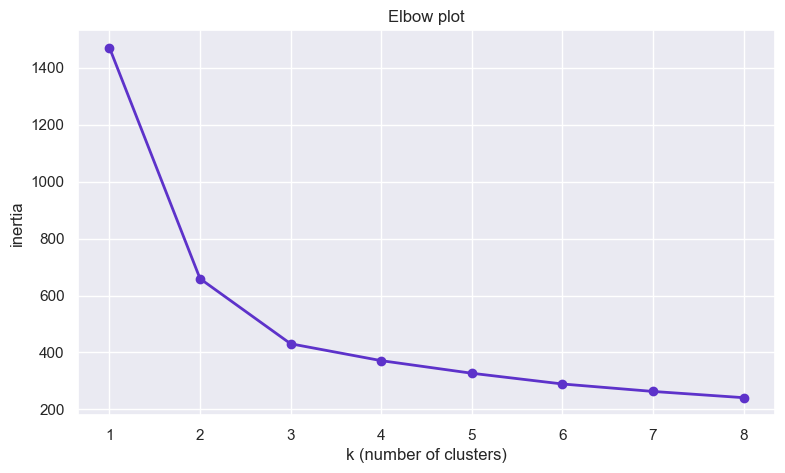

In [21]:
ks = range(1, 9)
inertias = [best_k_means(X, k)[2][-1] for k in ks]
plt.figure(figsize=(9, 5))
plt.plot(list(ks), inertias, "o-", color="#5d32ca", lw=2)
plt.xlabel("k (number of clusters)"); plt.ylabel("inertia")
plt.title("Elbow plot")
plt.show()

## Seeing the Clusters

Since I can't draw 7D, I plot just two of the features, kernel width and groove length, and color the points by their cluster. On the left is what K-Means decided using all 7 features; on the right is the truth, the actual varieties. They line up closely, which means the clustering found the real structure even though it never saw a label.

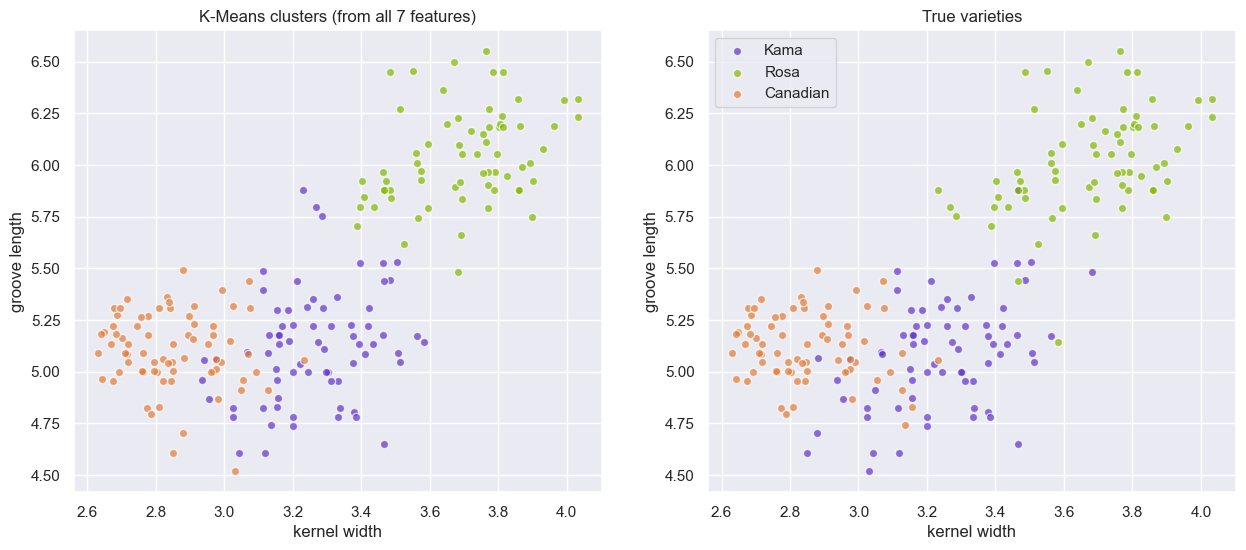

In [22]:
# Run best_k_means with k=3 on the full 7-feature standardized data
# and unpack the cluster labels, centroids, and inertia history
labels, C, _ = best_k_means(X, 3)

# We can't plot 7 dimensions, so pick two features to use as the x and y axes:
# kernel_width (column 4) and groove_length (column 6) from the raw (unscaled) data
wx, gx = 4, 6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: color each point by the cluster K-Means assigned it to
# Loop through clusters 0, 1, 2 and scatter their points separately so each gets its own color
for j in range(3):
    ax1.scatter(X_raw[labels == j, wx], X_raw[labels == j, gx], color=PALETTE[j], alpha=0.7, edgecolors="white", s=35)
ax1.set_title("K-Means clusters (from all 7 features)")

# Right plot: color each point by its true variety label for comparison
for j, name in enumerate(["Kama", "Rosa", "Canadian"]):
    m = true == name
    ax2.scatter(X_raw[m, wx], X_raw[m, gx], color=PALETTE[j], alpha=0.7, edgecolors="white", s=35, label=name)
ax2.set_title("True varieties")
ax2.legend()

for ax in (ax1, ax2):
    ax.set_xlabel("kernel width"); ax.set_ylabel("groove length")
plt.show()

## Validating Against the Real Labels

Since this is unsupervised, K-Means never sees the true variety labels, but because the seeds dataset happens to include them, I can check how well the discovered clusters line up with reality. The **crosstab** below cross-references each cluster with each variety: if the algorithm found the real structure, each cluster should be dominated by a single variety with only a few misplacements.

To put a single number on the quality, I use the **adjusted Rand index (ARI)**. It compares every pair of points and asks: did the clustering and the true labels agree on whether this pair belongs together or apart? The score is adjusted for chance, so 0 means the clustering is no better than random and 1.0 means a perfect match. K-Means lands around 0.77, which is a strong recovery of the three varieties from measurements alone. I also run scikit-learn's built-in `KMeans` to confirm the from-scratch implementation gets the same result.

In [23]:
print(pd.crosstab(pd.Series(labels, name="cluster"), pd.Series(true, name="variety")), "\n")
print(f"Adjusted Rand index (clusters vs true varieties): {adjusted_rand_score(true, labels):.2f}")

# Checking against scikit-learn
sk = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(X)
print(f"scikit-learn ARI: {adjusted_rand_score(true, sk):.2f}")

variety  Canadian  Kama  Rosa
cluster                      
0               4    62     5
1               0     2    65
2              66     6     0 

Adjusted Rand index (clusters vs true varieties): 0.77
scikit-learn ARI: 0.77


## Conclusion

Given seven measurements of 210 wheat kernels and no labels, K-Means split them into three groups that closely match the real varieties, an adjusted Rand index of about 0.77, with the from scratch version matching scikit-learn. That is the appeal of unsupervised learning: the structure was already in the measurements, and the algorithm surfaced it on its own, with the elbow plot independently pointing at k = 3.

This notebook also shows that clustering in many dimensions is no different from 2D, the distance formula just sums over all seven features and the centroids become seven-number averages. The only thing that breaks is the picture: I had to plot two features at a time and validate with a number instead of an eye, which is exactly the problem **PCA** solves later by squashing many features down to two for viewing.

The usual tradeoffs apply in that K-Means makes you choose k, its random starts mean I ran it several times and kept the tightest, and the features must be scaled so no single measurement dominates the distance. More fundamentally, it assumes clusters are roughly **round and similar-sized** and forces every kernel into a group, so it has no way to flag an oddly shaped cluster or a true outlier.